In [26]:
library(Signac)
library(Seurat)
library(GenomeInfoDb)
library(EnsDb.Hsapiens.v75)
library(ggplot2)
library(patchwork)
set.seed(1234)

res_dir='/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_cell_calling_comparison'
fragment.path = paste0(res_dir, '/union_bc_fragments.tsv.gz')
counts_pic_file=paste0(res_dir, '/NoDNAdebris_peaks/DownstreamReanalysis/bc_peak_pic_count.h5ad')
metadata_file=paste0(res_dir,'/Union_cell_3set_all_info.tsv')

library("anndata")
pic_h5 = read_h5ad(counts_pic_file) # cell-by-peak
counts_t = t(pic_h5$X)
colnames(counts_t) = pic_h5$obs[, 1]
rownames(counts_t) = pic_h5$var[, 1]



In [62]:
%matplotlib inline

ERROR: Error in parse(text = input): <text>:1:1: unexpected input
1: %matplotlib inline
    ^


In [27]:
metadata <- read.csv(
  file = metadata_file,
  header = TRUE,
  row.names = 1,
  sep='\t'
)
rownames(metadata) = paste0(rownames(metadata), '-1')


chrom_assay <- CreateChromatinAssay(
  counts = counts_t,
  sep = c(":", "-"),
  fragments = fragment.path,
  min.cells = 10,
  min.features = 10,
)

pbmc <- CreateSeuratObject(
  counts = chrom_assay,
  assay = "peaks",
  meta.data = metadata
)



Computing hash



In [28]:
pbmc

An object of class Seurat 
62449 features across 2384 samples within 1 assay 
Active assay: peaks (62449 features, 0 variable features)
 2 layers present: counts, data

In [29]:
dim(counts_t)

[1] 62477  2384

In [30]:
# check signac version
packageVersion("Signac")

[1] '1.13.0'

In [31]:
granges(pbmc)

GRanges object with 62449 ranges and 0 metadata columns:
            seqnames        ranges strand
               <Rle>     <IRanges>  <Rle>
      [1]       chr1 817032-817552      *
      [2]       chr1 826857-827828      *
      [3]       chr1 869606-870234      *
      [4]       chr1 903960-905713      *
      [5]       chr1 906614-907191      *
      ...        ...           ...    ...
  [62445] GL000218.1   83572-83864      *
  [62446] GL000218.1   97227-97458      *
  [62447] KI270721.1     2466-2624      *
  [62448] KI270726.1   27485-27707      *
  [62449] KI270713.1   21308-22396      *
  -------
  seqinfo: 44 sequences from an unspecified genome; no seqlengths

In [32]:
#remove the features that correspond to chromosome scaffolds e.g. (KI270713.1) or other sequences instead of the (22+2) standard chromosomes.
peaks.keep <- seqnames(granges(pbmc)) %in% standardChromosomes(granges(pbmc))
pbmc <- pbmc[as.vector(peaks.keep), ]

In [33]:
library(AnnotationHub)
ah <- AnnotationHub()

# Search for the Ensembl 98 EnsDb for Homo sapiens on AnnotationHub
query(ah, "EnsDb.Hsapiens.v98")

AnnotationHub with 1 record
# snapshotDate(): 2023-10-23
# names(): AH75011
# $dataprovider: Ensembl
# $species: Homo sapiens
# $rdataclass: EnsDb
# $rdatadateadded: 2019-05-02
# $title: Ensembl 98 EnsDb for Homo sapiens
# $description: Gene and protein annotations for Homo sapiens based on Ensem...
# $taxonomyid: 9606
# $genome: GRCh38
# $sourcetype: ensembl
# $sourceurl: http://www.ensembl.org
# $sourcesize: NA
# $tags: c("98", "AHEnsDbs", "Annotation", "EnsDb", "Ensembl", "Gene",
#   "Protein", "Transcript") 
# retrieve record with 'object[["AH75011"]]' 

In [ ]:
hg38_blacklist <- get("hg38.Kundaje.GRCh38_unified_blacklist")

# 3. View the GRanges object
print(hg38_blacklist)

In [34]:
ensdb_v98 <- ah[["AH75011"]]

loading from cache



In [35]:
# extract gene annotations from EnsDb
annotations <- GetGRangesFromEnsDb(ensdb = ensdb_v98)

# change to UCSC style since the data was mapped to hg38
seqlevels(annotations) <- paste0('chr', seqlevels(annotations))
genome(annotations) <- "hg38"

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

In [36]:
# add the gene information to the object
Annotation(pbmc) <- annotations

In [ ]:
# compute nucleosome signal score per cell
pbmc <- NucleosomeSignal(object = pbmc)

# compute TSS enrichment score per cell
pbmc <- TSSEnrichment(object = pbmc)

# # add fraction of reads in peaks
# pbmc$pct_reads_in_peaks <- pbmc$peak_region_fragments / pbmc$passed_filters * 100


Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score



ERROR: [1m[33mError[39m in `x[[i, drop = TRUE]]`:[22m
[33m![39m 'peak_region_fragments' not found in this Seurat object
 


In [43]:
# add blacklist ratio
blacklist_regions <- ah[['AH107305']] # blacklist regions for hg38
pbmc$blacklist_ratio <- FractionCountsInRegion(
  object = pbmc, 
  assay = 'peaks',
  regions = blacklist_regions
)

loading from cache



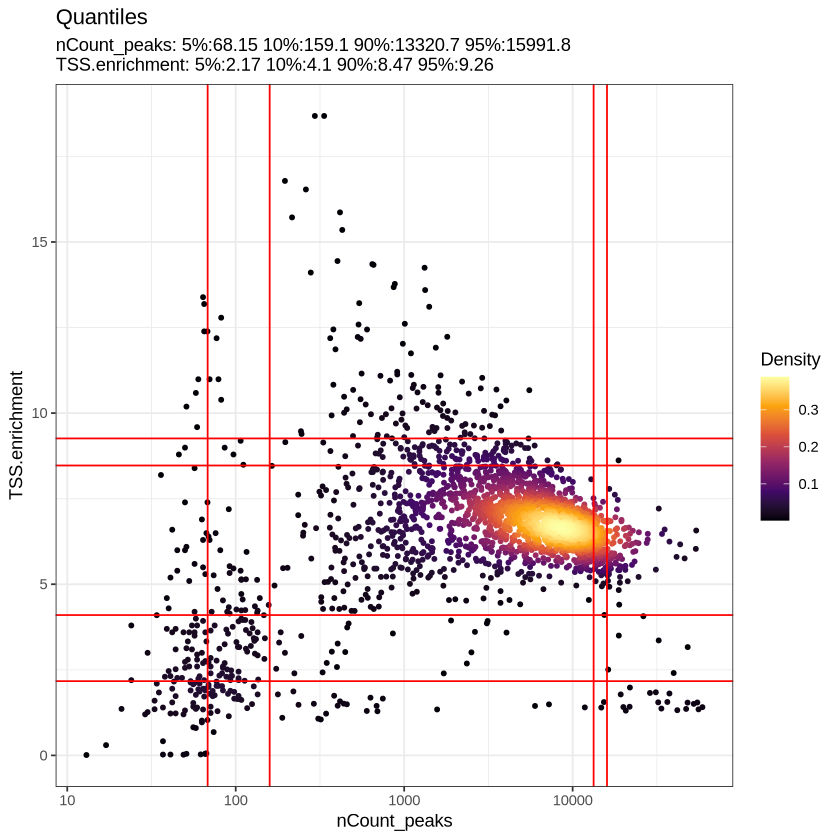

In [44]:
DensityScatter(pbmc, x = 'nCount_peaks', y = 'TSS.enrichment', log_x = TRUE, quantiles = TRUE)

In [72]:
library(dplyr)

summary_table <- pbmc@meta.data %>%
  group_by(X_3set_identified_by_atac) %>%
  summarize(
    count = n(),
    mean = mean(blacklist_ratio, na.rm = TRUE),
    median = median(blacklist_ratio, na.rm = TRUE),
    sd = sd(blacklist_ratio, na.rm = TRUE),
    min = min(blacklist_ratio, na.rm = TRUE),
    max = max(blacklist_ratio, na.rm = TRUE)
  )

print(summary_table)


Attaching package: 'dplyr'


The following objects are masked from 'package:dbplyr':

    ident, sql


The following objects are masked from 'package:ensembldb':

    filter, select


The following object is masked from 'package:AnnotationDbi':

    select


The following object is masked from 'package:Biobase':

    combine


The following objects are masked from 'package:GenomicRanges':

    intersect, setdiff, union


The following object is masked from 'package:GenomeInfoDb':

    intersect


The following objects are masked from 'package:IRanges':

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from 'package:S4Vectors':

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from 'package:BiocGenerics':

    combine, intersect, setdiff, union


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, 

# A tibble: 7 × 7
  X_3set_identified_by_atac count       mean median        sd   min      max
  <chr>                     <int>      <dbl>  <dbl>     <dbl> <dbl>    <dbl>
1 CR unique                    61 0.000185        0 0.000735      0 0.00498 
2 CR+TSS, not SADE             33 0.0000580       0 0.000250      0 0.00133 
3 SADE unique                 118 0.0000186       0 0.000202      0 0.00219 
4 SADE+CR, not TSS             73 0.00000733      0 0.0000315     0 0.000187
5 SADE+TSS, not CR            118 0.0000366       0 0.000137      0 0.00101 
6 TSS unique                  189 0               0 0             0 0       
7 common                     1792 0.0000632       0 0.000145      0 0.00171 


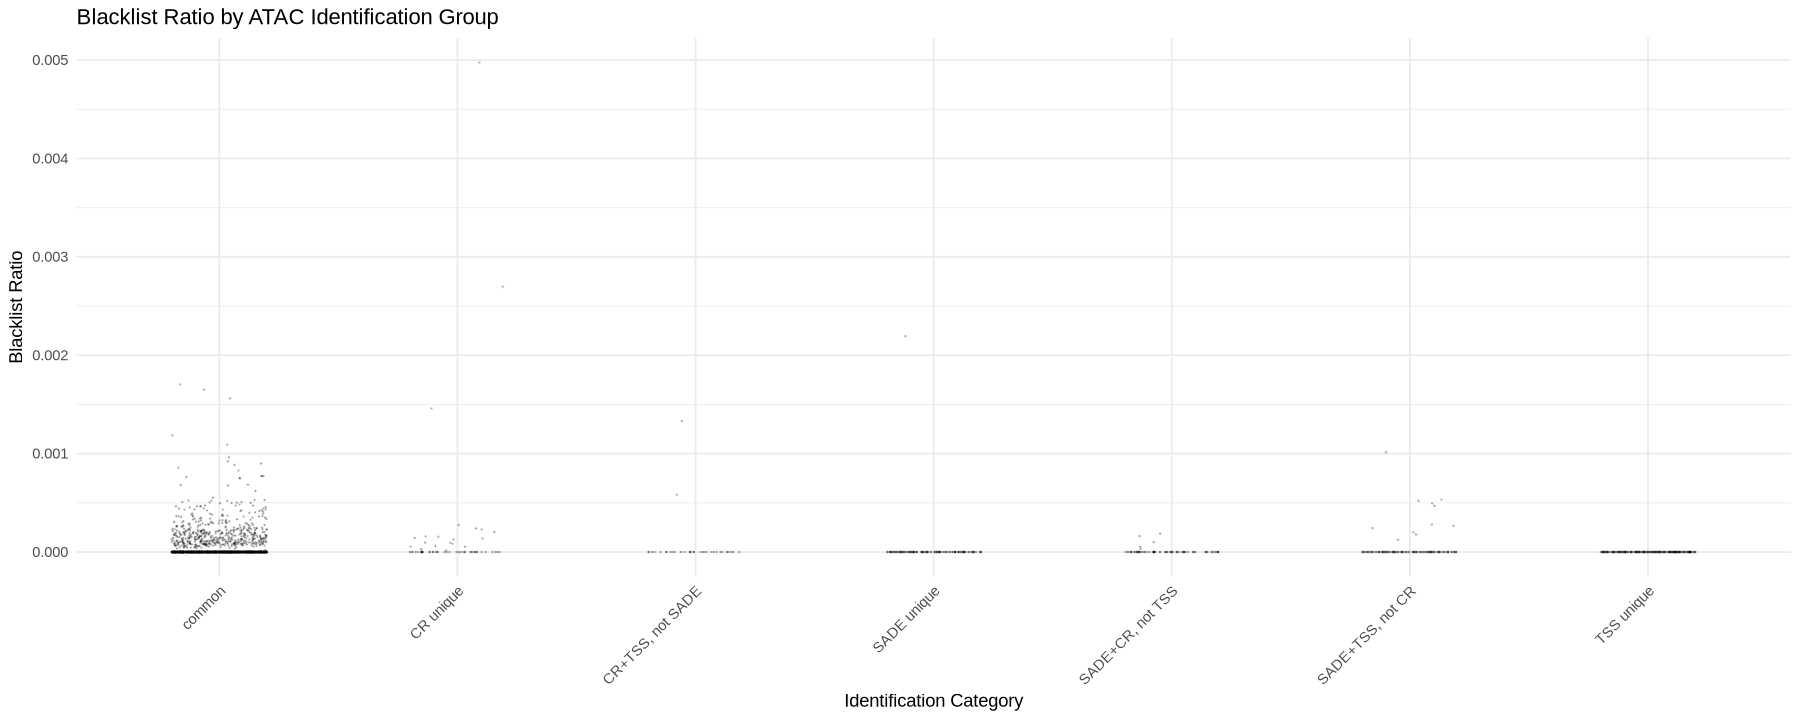

In [73]:
library(ggplot2)

options(repr.plot.width = 15, repr.plot.height = 6)

df <- pbmc@meta.data

# 2. Create the plot
ggplot(df, aes(x = X_3set_identified_by_atac, y = blacklist_ratio, fill = X_3set_identified_by_atac)) +
  #geom_violin(trim = FALSE, scale = "width") +
  geom_jitter(size = 0.1, alpha = 0.2, width = 0.2) +  # Adds points to see density
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1), # Tilts labels if they are long
    legend.position = "none"                          # Removes redundant legend
  ) +
  labs(
    title = "Blacklist Ratio by ATAC Identification Group",
    x = "Identification Category",
    y = "Blacklist Ratio"
  )

In [66]:

VlnPlot(
  object = pbmc,
  features = c('nCount_peaks', 'TSS.enrichment', 'blacklist_ratio', 'nucleosome_signal'),
  pt.size = 0.1,
  ncol = 2
)


In [64]:

p1 <- VlnPlot(pbmc, features = 'nCount_peaks', group.by = 'X_3set_identified_by_atac')
p2 <- VlnPlot(pbmc, features = 'TSS.enrichment', group.by = 'X_3set_identified_by_atac')
p3 <- VlnPlot(pbmc, features = 'blacklist_ratio', group.by = 'X_3set_identified_by_atac')
p4 <- VlnPlot(pbmc, features = 'nucleosome_signal', group.by = 'X_3set_identified_by_atac')

(p1 + p2) / (p3 + p4)

Warning message:
"Removed 29 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 14 rows containing missing values or values outside the scale range
(`geom_bar()`)."


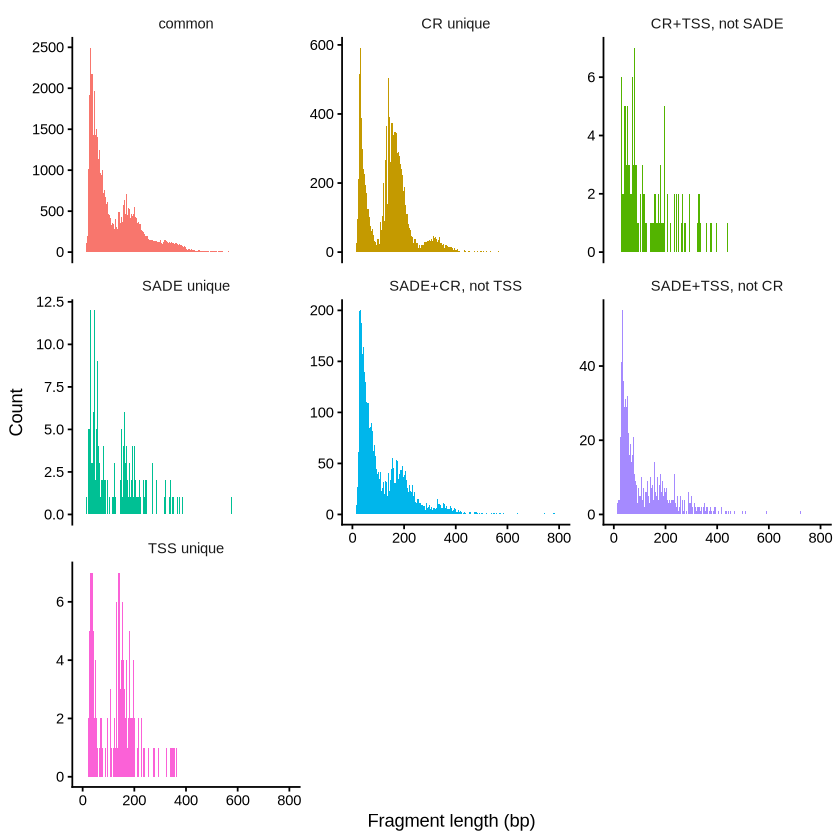

In [67]:

FragmentHistogram(object = pbmc, group.by = 'X_3set_identified_by_atac')